In [1]:
import sys
from pathlib import Path

sys.path.append(
    str(Path("..").resolve())
)

In [2]:
from scripts.performance_loader import load_data

nav, perf = load_data()

print(nav.shape)
print(perf.shape)

nav.head()

(46000, 3)
(40, 19)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
print(nav.columns.tolist())
print(perf.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [4]:
from scripts.return_analysis import calculate_daily_returns

nav = calculate_daily_returns(nav)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


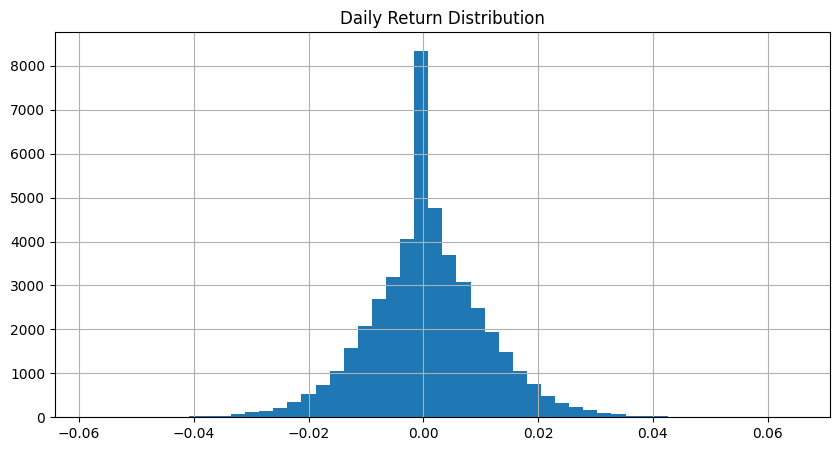

In [5]:
import matplotlib.pyplot as plt

nav["daily_return"].dropna().hist(
    bins=50,
    figsize=(10,5)
)

plt.title("Daily Return Distribution")
plt.show()

In [6]:
from scripts.return_analysis import calculate_cagr

cagr_df = calculate_cagr(nav)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
from pathlib import Path

output_dir = Path("../reports/outputs")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

cagr_df.to_csv(
    output_dir / "cagr_table.csv",
    index=False
)

In [8]:
from scripts.risk_analysis import sharpe_ratio

sharpe_df = sharpe_ratio(nav)

sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head()

,amfi_code,sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [9]:
from scripts.risk_analysis import sortino_ratio

sortino_df = sortino_ratio(nav)

sortino_df.sort_values(
    "sortino",
    ascending=False
).head()

,amfi_code,sortino
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [10]:
from scripts.risk_analysis import max_drawdown

drawdown_df = max_drawdown(nav)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [11]:
import pandas as pd

benchmark = pd.read_csv(
    "../data/raw/nifty100.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark.head()

,date,close
0,2022-01-03,17874.000000
1,2022-01-04,18030.949219
2,2022-01-05,18147.500000
3,2022-01-06,17985.599609
4,2022-01-07,18053.949219


In [12]:
from scripts.alpha_beta_analysis import alpha_beta

alpha_beta_df = alpha_beta(
    nav,
    benchmark
)

alpha_beta_df.head()

datetime64[us]
datetime64[us]
Fund 100016
Merged rows: 983
   amfi_code       date       nav  daily_return         close  \
0     100016 2022-01-03  520.4608           NaN  17874.000000   
1     100016 2022-01-04  515.0971     -0.010306  18030.949219   
2     100016 2022-01-05  521.7239      0.012865  18147.500000   
3     100016 2022-01-06  515.7880     -0.011377  17985.599609   
4     100016 2022-01-07  515.1639     -0.001210  18053.949219   

   benchmark_return  
0               NaN  
1          0.008781  
2          0.006464  
3         -0.008921  
4          0.003800  
NAV range:
2022-01-03 00:00:00 2026-05-29 00:00:00

Benchmark range:
2022-01-03 00:00:00 2025-12-31 00:00:00
Fund 100025
Merged rows: 983
   amfi_code       date      nav  daily_return         close  benchmark_return
0     100025 2022-01-03  26.3169           NaN  17874.000000               NaN
1     100025 2022-01-04  26.2234     -0.003553  18030.949219          0.008781
2     100025 2022-01-05  26.2221     -0.000

,amfi_code,alpha,beta
0,100016,0.059619,0.056455
1,100025,0.054792,-0.010935
2,100033,0.233664,-0.002593
3,101206,0.141329,0.034864
4,101207,0.129441,0.110101


In [13]:
alpha_beta_df.to_csv(
    "../reports/outputs/alpha_beta.csv",
    index=False
)

print("Saved alpha_beta.csv")

Saved alpha_beta.csv


In [14]:
from scripts.scorecard_analysis import build_scorecard

scorecard = build_scorecard(
    cagr_df,
    sharpe_df,
    alpha_beta_df,
    drawdown_df
)

scorecard.head()

,amfi_code,cagr,sharpe,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,score
0,100016,0.026352,-0.201517,0.059619,0.056455,-0.247344,0.100,0.150,0.175,0.850,18.750
1,100025,0.044551,-0.567095,0.054792,-0.010935,-0.043083,0.125,0.050,0.100,0.100,8.000
2,100033,0.300997,1.093699,0.233664,-0.002593,-0.162172,0.850,0.850,0.800,0.500,67.750
3,101206,0.235205,1.027213,0.141329,0.034864,-0.112916,0.725,0.800,0.475,0.225,53.500
4,101207,0.079331,0.162661,0.129441,0.110101,-0.354469,0.350,0.325,0.400,0.950,36.125


In [15]:
scorecard.to_csv(
    "../reports/outputs/fund_scorecard.csv",
    index=False
)

print("Saved fund_scorecard.csv")

Saved fund_scorecard.csv


In [16]:
scorecard.sort_values(
    "score",
    ascending=False
).head(10)

,amfi_code,cagr,sharpe,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,dd_rank,score
25,120505,0.328016,1.180101,0.285787,0.018188,-0.181885,1.000,0.900,0.925,0.625,77.250
39,149324,0.322621,0.949796,0.303951,-0.040420,-0.311719,0.950,0.700,1.000,0.925,75.250
21,119598,0.323981,0.945308,0.290381,-0.066406,-0.287060,0.975,0.675,0.950,0.900,74.125
34,148567,0.309499,1.448291,0.292382,0.016402,-0.112657,0.900,1.000,0.975,0.200,73.500
36,148569,0.319245,1.234930,0.226913,0.022806,-0.163967,0.925,0.950,0.775,0.525,72.250
30,120843,0.308833,1.306744,0.259556,-0.050150,-0.129740,0.875,0.975,0.875,0.325,71.375
38,149323,0.295581,1.132122,0.270396,0.000524,-0.172481,0.825,0.875,0.900,0.550,70.125
2,100033,0.300997,1.093699,0.233664,-0.002593,-0.162172,0.850,0.850,0.800,0.500,67.750
16,119094,0.281926,0.998231,0.241069,-0.034592,-0.209609,0.800,0.750,0.825,0.700,66.250
19,119551,0.257849,1.208267,0.196791,0.052420,-0.150124,0.775,0.925,0.700,0.425,64.625


In [17]:
from scripts.benchmark_analysis import benchmark_chart

benchmark_chart(nav)

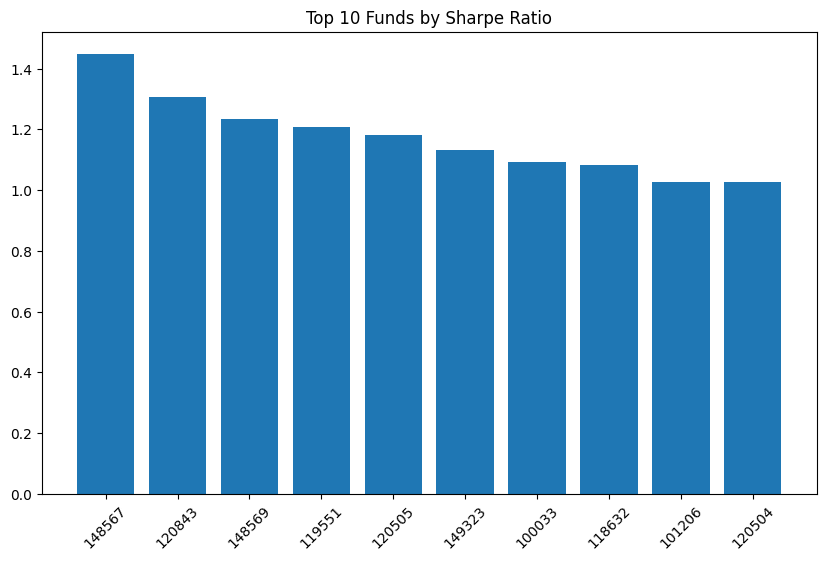

In [18]:
import matplotlib.pyplot as plt

top = sharpe_df.sort_values(
    "sharpe",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top["amfi_code"].astype(str),
    top["sharpe"]
)

plt.xticks(rotation=45)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

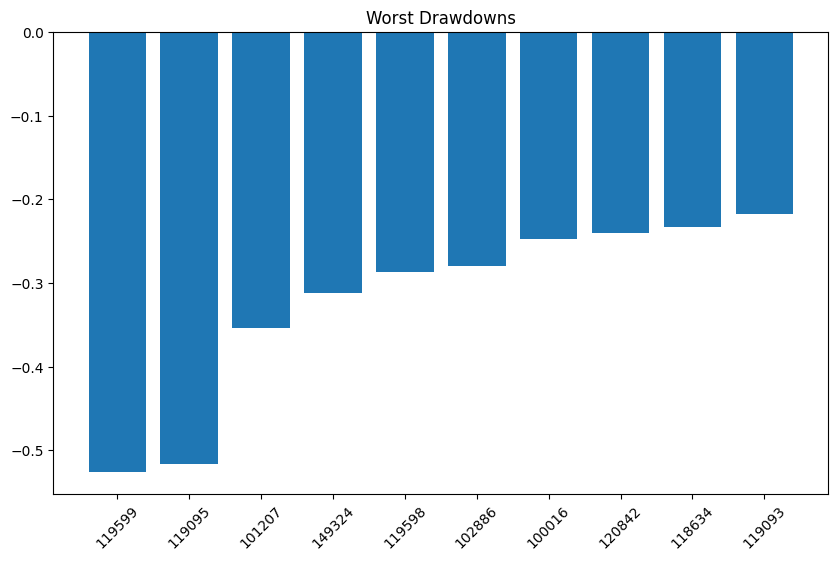

In [19]:
worst = drawdown_df.sort_values(
    "max_drawdown"
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    worst["amfi_code"].astype(str),
    worst["max_drawdown"]
)

plt.xticks(rotation=45)

plt.title("Worst Drawdowns")

plt.show()

In [20]:
print("Total Funds:", nav["amfi_code"].nunique())

print(
    "Best Fund:",
    scorecard.sort_values(
        "score",
        ascending=False
    ).iloc[0]["amfi_code"]
)

Total Funds: 40
Best Fund: 120505.0
